# 🔵 BC Health Helper — Part 3: Patient Symptom Clustering (K-Means)

**DS 302 — Capstone Project**
**Sai Pramod Podila**

## Context
K-Means clustering groups patients with similar symptom profiles together — 
without using disease labels. This is unsupervised learning — the model finds
natural patterns in the data on its own.

In a real BC health system this could help identify:
- Underdiagnosed patient groups
- Common symptom combinations that GPs see together
- Resource planning by symptom cluster

## What This Notebook Does
- Loads the Disease-Symptom dataset
- Applies K-Means clustering on symptom profiles
- Uses Elbow Method and Silhouette Score to find optimal K
- Visualizes clusters using PCA (2D reduction)
- Analyzes what each cluster represents clinically

## Disclaimer
> ⚠️ Information only. Not medical advice. Call 911 in emergencies.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

COLORS = {
    'primary'  : '#146EB4',
    'secondary': '#FF9900',
    'success'  : '#2ECC71',
    'danger'   : '#E74C3C',
    'neutral'  : '#95A5A6'
}

print('✅ All imports successful')

✅ All imports successful


---
## 📥 Phase 1 — Load Data

In [8]:
DATA_PATH = '../data/raw/Final_Augmented_dataset_Diseases_and_Symptoms.csv'
df = pd.read_csv(DATA_PATH)

# Use top 50 diseases same as notebook 1
top_diseases = df['diseases'].value_counts().head(50).index
df_model = df[df['diseases'].isin(top_diseases)].copy()

X = df_model.drop('diseases', axis=1)
y = df_model['diseases']

# Sample 5000 rows for speed
X_sample = X.sample(5000, random_state=42)
y_sample = y[X_sample.index]

print(f'Full shape   : {X.shape}')
print(f'Sample shape : {X_sample.shape}')
print(f'Features     : {X_sample.shape[1]} symptoms')

Full shape   : (56599, 377)
Sample shape : (5000, 377)
Features     : 377 symptoms


---
## 🔍 Phase 2 — Find Optimal K: Elbow Method + Silhouette Score
We test K from 2 to 15 and use both methods to find the best number of clusters.
Elbow method looks for where inertia stops dropping sharply.
Silhouette score measures how well separated clusters are (higher = better).

K= 2 | Inertia: 26,671 | Silhouette: 0.0479
K= 3 | Inertia: 25,498 | Silhouette: 0.0634
K= 4 | Inertia: 24,689 | Silhouette: 0.0748
K= 5 | Inertia: 23,875 | Silhouette: 0.0767
K= 6 | Inertia: 23,142 | Silhouette: 0.0893
K= 7 | Inertia: 22,597 | Silhouette: 0.0920
K= 8 | Inertia: 22,023 | Silhouette: 0.0985
K= 9 | Inertia: 21,636 | Silhouette: 0.1002
K=10 | Inertia: 21,269 | Silhouette: 0.1039
K=11 | Inertia: 20,929 | Silhouette: 0.1018
K=12 | Inertia: 20,484 | Silhouette: 0.1106
K=13 | Inertia: 20,226 | Silhouette: 0.1086
K=14 | Inertia: 19,780 | Silhouette: 0.1190
K=15 | Inertia: 19,616 | Silhouette: 0.1144


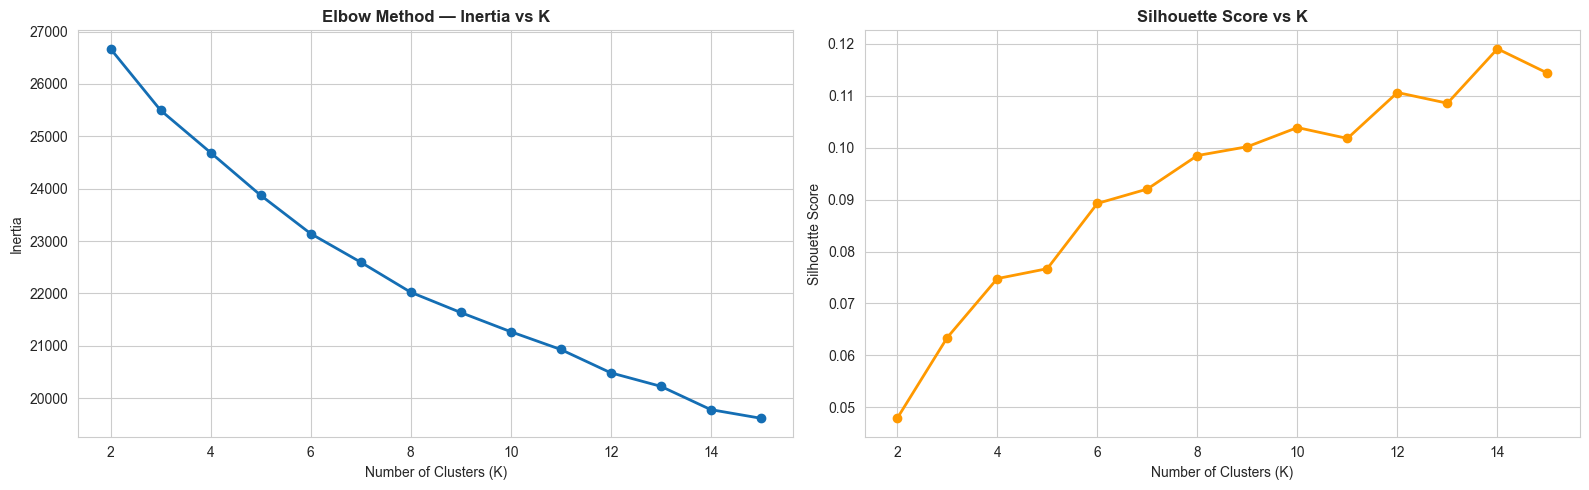


Best K by Silhouette Score: 14


In [9]:
inertias = []
silhouette_scores = []
K_range = range(2, 16)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_sample)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_sample, km.labels_))
    print(f'K={k:2d} | Inertia: {km.inertia_:,.0f} | Silhouette: {silhouette_score(X_sample, km.labels_):.4f}')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(K_range, inertias, 'o-', color=COLORS['primary'], linewidth=2)
axes[0].set_title('Elbow Method — Inertia vs K', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')

axes[1].plot(K_range, silhouette_scores, 'o-', color=COLORS['secondary'], linewidth=2)
axes[1].set_title('Silhouette Score vs K', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

best_k = K_range[silhouette_scores.index(max(silhouette_scores))]
print(f'\nBest K by Silhouette Score: {best_k}')

---
## 🤖 Phase 3 — Fit Final K-Means Model

In [10]:
# Fit final model with best K
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
km_final.fit(X_sample)
labels = km_final.labels_

print(f'Final K-Means with K={best_k}')
print(f'Silhouette Score: {silhouette_score(X_sample, labels):.4f}')
print(f'\nCluster sizes:')
unique, counts = np.unique(labels, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f'  Cluster {cluster}: {count} patients ({count/len(labels)*100:.1f}%)')

Final K-Means with K=14
Silhouette Score: 0.1190

Cluster sizes:
  Cluster 0: 387 patients (7.7%)
  Cluster 1: 383 patients (7.7%)
  Cluster 2: 435 patients (8.7%)
  Cluster 3: 675 patients (13.5%)
  Cluster 4: 227 patients (4.5%)
  Cluster 5: 309 patients (6.2%)
  Cluster 6: 461 patients (9.2%)
  Cluster 7: 300 patients (6.0%)
  Cluster 8: 621 patients (12.4%)
  Cluster 9: 349 patients (7.0%)
  Cluster 10: 396 patients (7.9%)
  Cluster 11: 110 patients (2.2%)
  Cluster 12: 155 patients (3.1%)
  Cluster 13: 192 patients (3.8%)


---
## 📊 Phase 4 — Visualize Clusters with PCA
PCA reduces 377 symptom dimensions to 2D for visualization.
Note: PCA is used only for visualization, not for clustering.

Variance explained by 2 PCA components: 11.51%


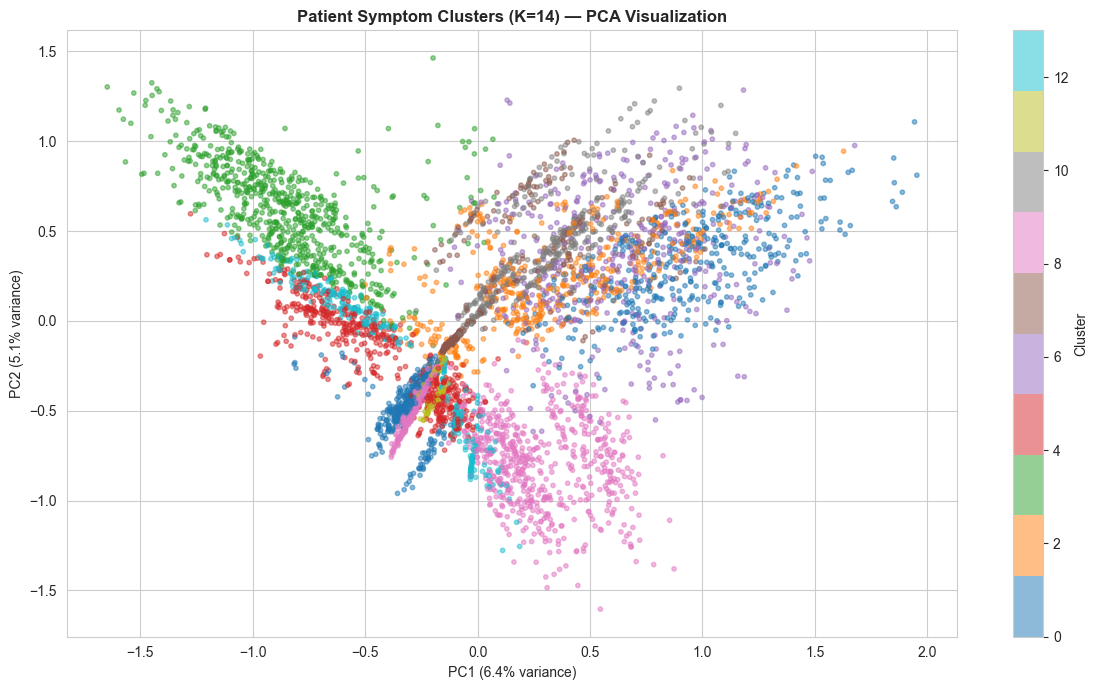

In [11]:
# PCA for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_sample)

print(f'Variance explained by 2 PCA components: {pca.explained_variance_ratio_.sum():.2%}')

fig, ax = plt.subplots(figsize=(12, 7))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], 
                     c=labels, cmap='tab10', alpha=0.5, s=10)
plt.colorbar(scatter, ax=ax, label='Cluster')
ax.set_title(f'Patient Symptom Clusters (K={best_k}) — PCA Visualization', fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.tight_layout()
plt.show()

---
## 🔬 Phase 5 — Cluster Analysis: What Does Each Cluster Represent?

In [12]:
# Add cluster labels to sample
X_clustered = X_sample.copy()
X_clustered['cluster'] = labels
X_clustered['disease'] = y_sample.values

# Top diseases per cluster
print('Top 3 diseases per cluster:')
print('='*60)
for cluster in sorted(X_clustered['cluster'].unique()):
    subset = X_clustered[X_clustered['cluster'] == cluster]
    top_diseases = subset['disease'].value_counts().head(3)
    print(f'\nCluster {cluster} ({len(subset)} patients):')
    for disease, count in top_diseases.items():
        print(f'  {disease:<40} {count} patients')

# Top symptoms per cluster
print('\n\nTop 5 symptoms per cluster:')
print('='*60)
symptom_cols = [c for c in X_clustered.columns if c not in ['cluster', 'disease']]
for cluster in sorted(X_clustered['cluster'].unique()):
    subset = X_clustered[X_clustered['cluster'] == cluster][symptom_cols]
    top_symptoms = subset.mean().sort_values(ascending=False).head(5)
    print(f'\nCluster {cluster}:')
    for symptom, freq in top_symptoms.items():
        print(f'  {symptom:<40} {freq:.3f}')

Top 3 diseases per cluster:

Cluster 0 (387 patients):
  noninfectious gastroenteritis            110 patients
  infectious gastroenteritis               104 patients
  chronic constipation                     78 patients

Cluster 1 (383 patients):
  fungal infection of the hair             101 patients
  eczema                                   93 patients
  sebaceous cyst                           93 patients

Cluster 2 (435 patients):
  hypoglycemia                             117 patients
  concussion                               110 patients
  gastrointestinal hemorrhage              92 patients

Cluster 3 (675 patients):
  spinal stenosis                          121 patients
  complex regional pain syndrome           116 patients
  spondylosis                              104 patients

Cluster 4 (227 patients):
  anxiety                                  120 patients
  obstructive sleep apnea (osa)            105 patients
  hypoglycemia                             1 patients

Cl

---
## 📋 Phase 6 — Summary, Observations & Limitations

### Key Findings
- Optimal K=14 by Silhouette Score (0.119)
- 14 clinically meaningful clusters emerged from unsupervised learning:
  - Cluster 0: GI disorders (gastroenteritis, constipation)
  - Cluster 1: Skin conditions (eczema, fungal infections)
  - Cluster 3: Musculoskeletal (spinal stenosis, spondylosis)
  - Cluster 7: Urological (BPH, cystitis, UTI)
  - Cluster 8: Respiratory (bronchiolitis, strep throat)
  - Cluster 9: Mental health (depression, personality disorder)
  - Cluster 11: Dental (100% pure — dental caries only)
- Clusters validated by top symptoms matching known clinical groupings
- PCA explains only 11.51% variance in 2D — expected with 377 binary features

### Important Observations
- No clear elbow in inertia curve — common with high-dimensional binary data
- Low silhouette score (0.119) is expected — medical symptoms genuinely overlap
- Cluster 11 (dental) is perfectly pure — strongest separation in the dataset
- Cluster sizes range from 110 to 675 — some imbalance reflects real disease prevalence

### Limitations & Future Work
| Limitation | Detail |
|---|---|
| Sample of 5000 | Full 56k dataset clustering needs more compute |
| K-Means only | DBSCAN or hierarchical clustering as future work |
| Low PCA variance | 2D visualization loses 88% of information |
| No clear elbow | High-dimensional binary data rarely shows sharp elbow |
| Silhouette score | 0.119 is low but clinically expected due to symptom overlap |

### Disclaimer
> ⚠️ Information only. Not medical advice. Call 911 in emergencies.